<a href="https://colab.research.google.com/github/sp3jossy/DS_Machine-Learning_Projects/blob/Supervised-Learning/Copy_of_JA_kaggle_HousingProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **OVERVIEW**

Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

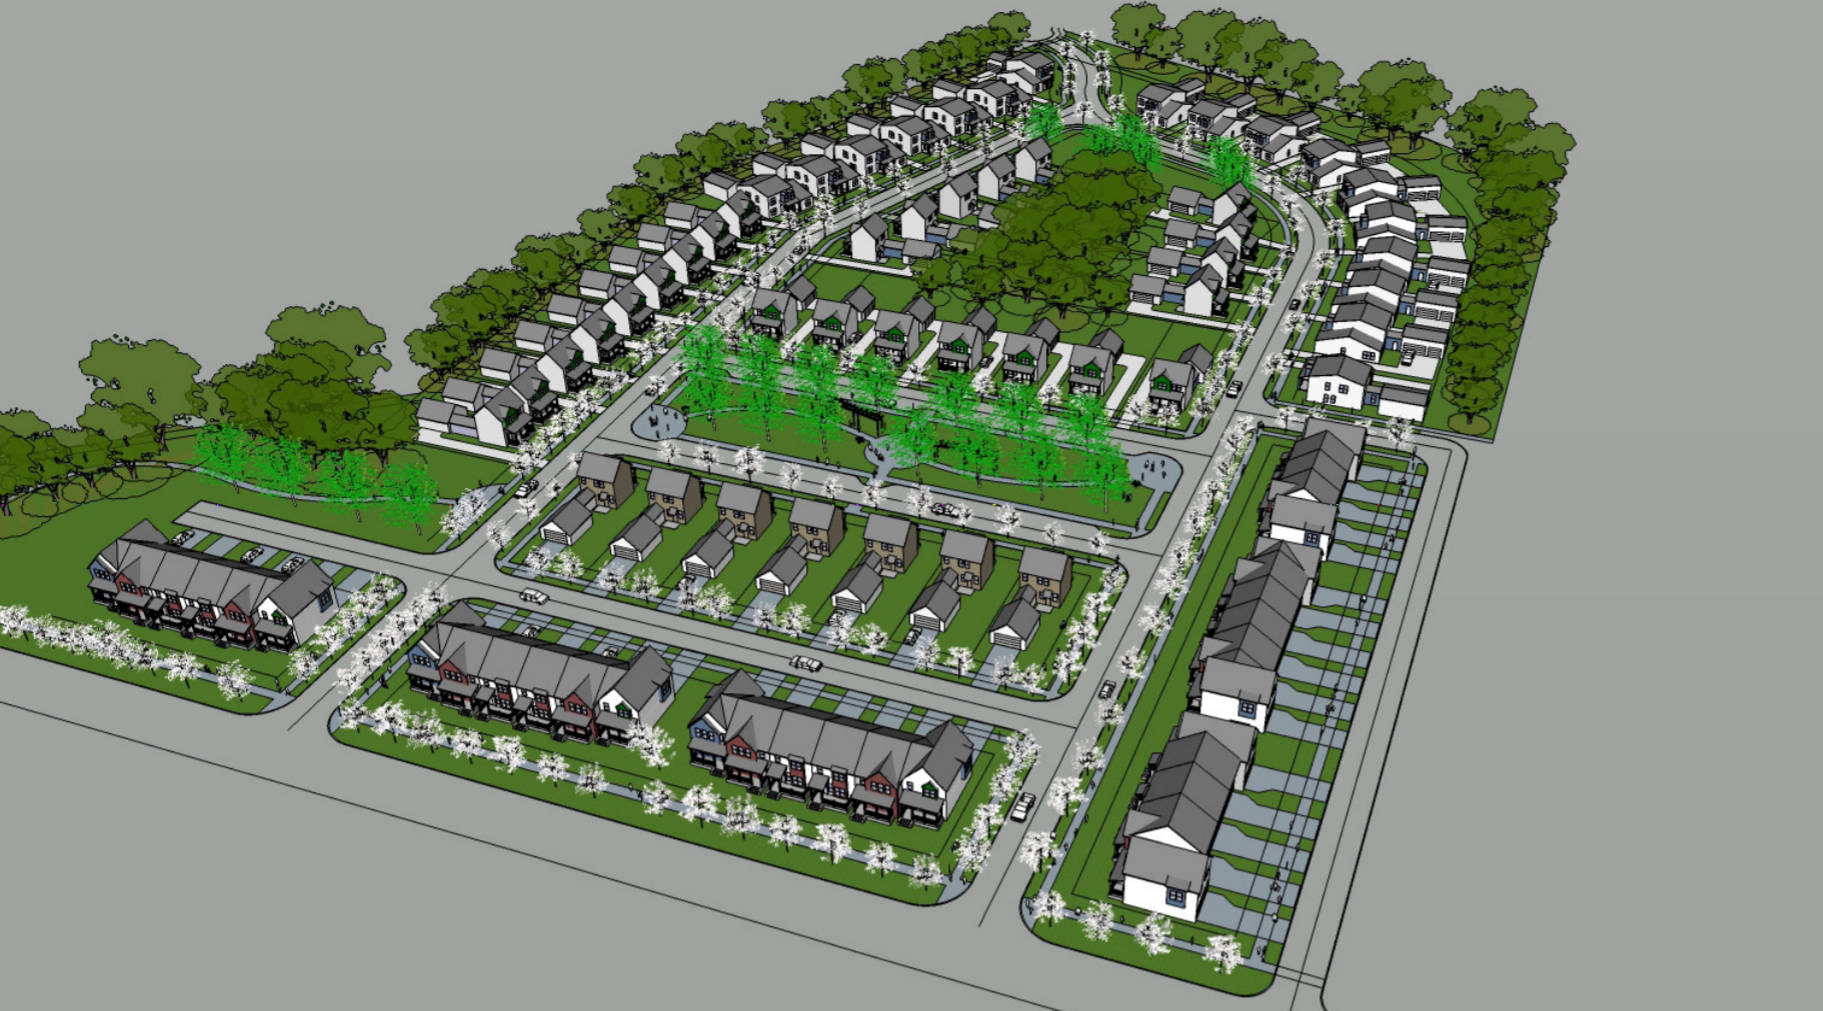

## **Data fields**

Here's a brief version of what you'll find in the data description file.

| | |
| :--- | :--- |
| * **SalePrice**: The property's sale price in dollars. This is the target variable. | * **YearBuilt**: Original construction date |
| * **MSSubClass**: The building class | * **YearRemodAdd**: Remodel date |
| * **MSZoning**: The general zoning classification | * **RoofStyle**: Type of roof |
| * **LotFrontage**: Linear feet of street connected to property | * **RoofMatl**: Roof material |
| * **LotArea**: Lot size in square feet | * **Exterior1st**: Exterior covering on house |
| * **Street**: Type of road access | * **Exterior2nd**: Exterior covering on house (if more than one material) |
| * **Alley**: Type of alley access | * **MasVnrType**: Masonry veneer type |
| * **LotShape**: General shape of property | * **MasVnrArea**: Masonry veneer area in square feet |
| * **LandContour**: Flatness of the property | * **ExterQual**: Exterior material quality |
| * **Utilities**: Type of utilities available | * **ExterCond**: Present condition of the material on the exterior |
| * **LotConfig**: Lot configuration | * **Foundation**: Type of foundation |
| * **LandSlope**: Slope of property | * **BsmtQual**: Height of the basement |
| * **Neighborhood**: Physical locations within Ames city limits | * **BsmtCond**: General condition of the basement |
| * **Condition1**: Proximity to main road or railroad | * **BsmtExposure**: Walkout or garden level basement walls |
| * **Condition2**: Proximity to main road or railroad (if a second is present) | * **BsmtFinType1**: Quality of basement finished area |
| * **BldgType**: Type of dwelling | * **BsmtFinSF1**: Type 1 finished square feet |
| * **HouseStyle**: Style of dwelling | * **BsmtFinType2**: Quality of second finished area (if present) |
| * **OverallQual**: Overall material and finish quality | * **BsmtFinSF2**: Type 2 finished square feet |
| * **OverallCond**: Overall condition rating | * **BsmtUnfSF**: Unfinished square feet of basement area |
| * **TotalBsmtSF**: Total square feet of basement area | * **Heating**: Type of heating |
| * **HeatingQC**: Heating quality and condition | * **CentralAir**: Central air conditioning |
| * **Electrical**: Electrical system | * **1stFlrSF**: First Floor square feet |
| * **2ndFlrSF**: Second floor square feet | * **LowQualFinSF**: Low quality finished square feet (all floors) |
| * **GrLivArea**: Above grade (ground) living area square feet | * **BsmtFullBath**: Basement full bathrooms |
| * **BsmtHalfBath**: Basement half bathrooms | * **FullBath**: Full bathrooms above grade |
| * **HalfBath**: Half baths above grade | * **Bedroom**: Number of bedrooms above basement level |
| * **Kitchen**: Number of kitchens | * **KitchenQual**: Kitchen quality |
| * **TotRmsAbvGrd**: Total rooms above grade (does not include bathrooms) | * **Functional**: Home functionality rating |
| * **Fireplaces**: Number of fireplaces | * **FireplaceQu**: Fireplace quality |
| * **GarageType**: Garage location | * **GarageYrBlt**: Year garage was built |
| * **GarageFinish**: Interior finish of the garage | * **GarageCars**: Size of garage in car capacity |
| * **GarageArea**: Size of garage in square feet | * **GarageQual**: Garage quality |
| * **GarageCond**: Garage condition | * **PavedDrive**: Paved driveway |
| * **WoodDeckSF**: Wood deck area in square feet | * **OpenPorchSF**: Open porch area in square feet |
| * **EnclosedPorch**: Enclosed porch area in square feet | * **3SsnPorch**: Three season porch area in square feet |
| * **ScreenPorch**: Screen porch area in square feet | * **PoolArea**: Pool area in square feet |
| * **PoolQC**: Pool quality | * **Fence**: Fence quality |
| * **MiscFeature**: Miscellaneous feature not covered in other categories | * **MiscVal**: $Value of miscellaneous feature |
| * **MoSold**: Month Sold | * **YrSold**: Year Sold |
| * **SaleType**: Type of sale | * **SaleCondition**: Condition of sale |

## Importing Libraries

In [ ]:
# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings('ignore')

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Libraries to split data, impute missing values
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


#Libraries for Linear Regression models,tune model, get different metric scores
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge



## Loading and Overview of Datasets

In [ ]:
# to get data from kaggle site
train = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

In [ ]:
print(f"The Training data has {train.shape[0]} rows and {train.shape[1]} columns.")
print("**"*50)
print(f"The Test data has {test.shape[0]} rows and {test.shape[1]} columns.")
print("**"*50)
train.head()

The Training data has 1460 rows and 81 columns.
****************************************************************************************************
The Test data has 1459 rows and 80 columns.
****************************************************************************************************


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train.info()
print("**"*50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Exploratory Data Analysis

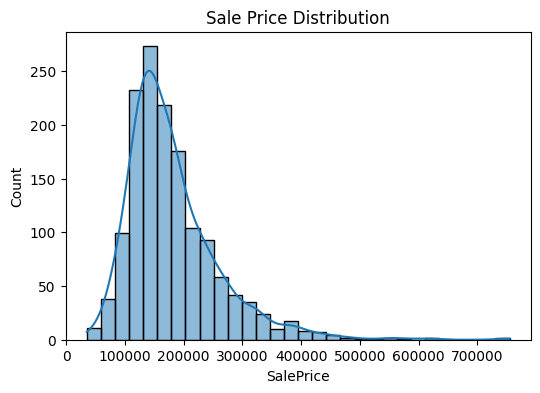

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(train["SalePrice"], bins=30, kde=True)
plt.title("Sale Price Distribution")
plt.show();

The distribution of SalePrice is right-skewed or positively skewed indicating that most of the data points are concentrated on the left side of the plot (lower prices), while a smaller number of higher prices trail off to the right.

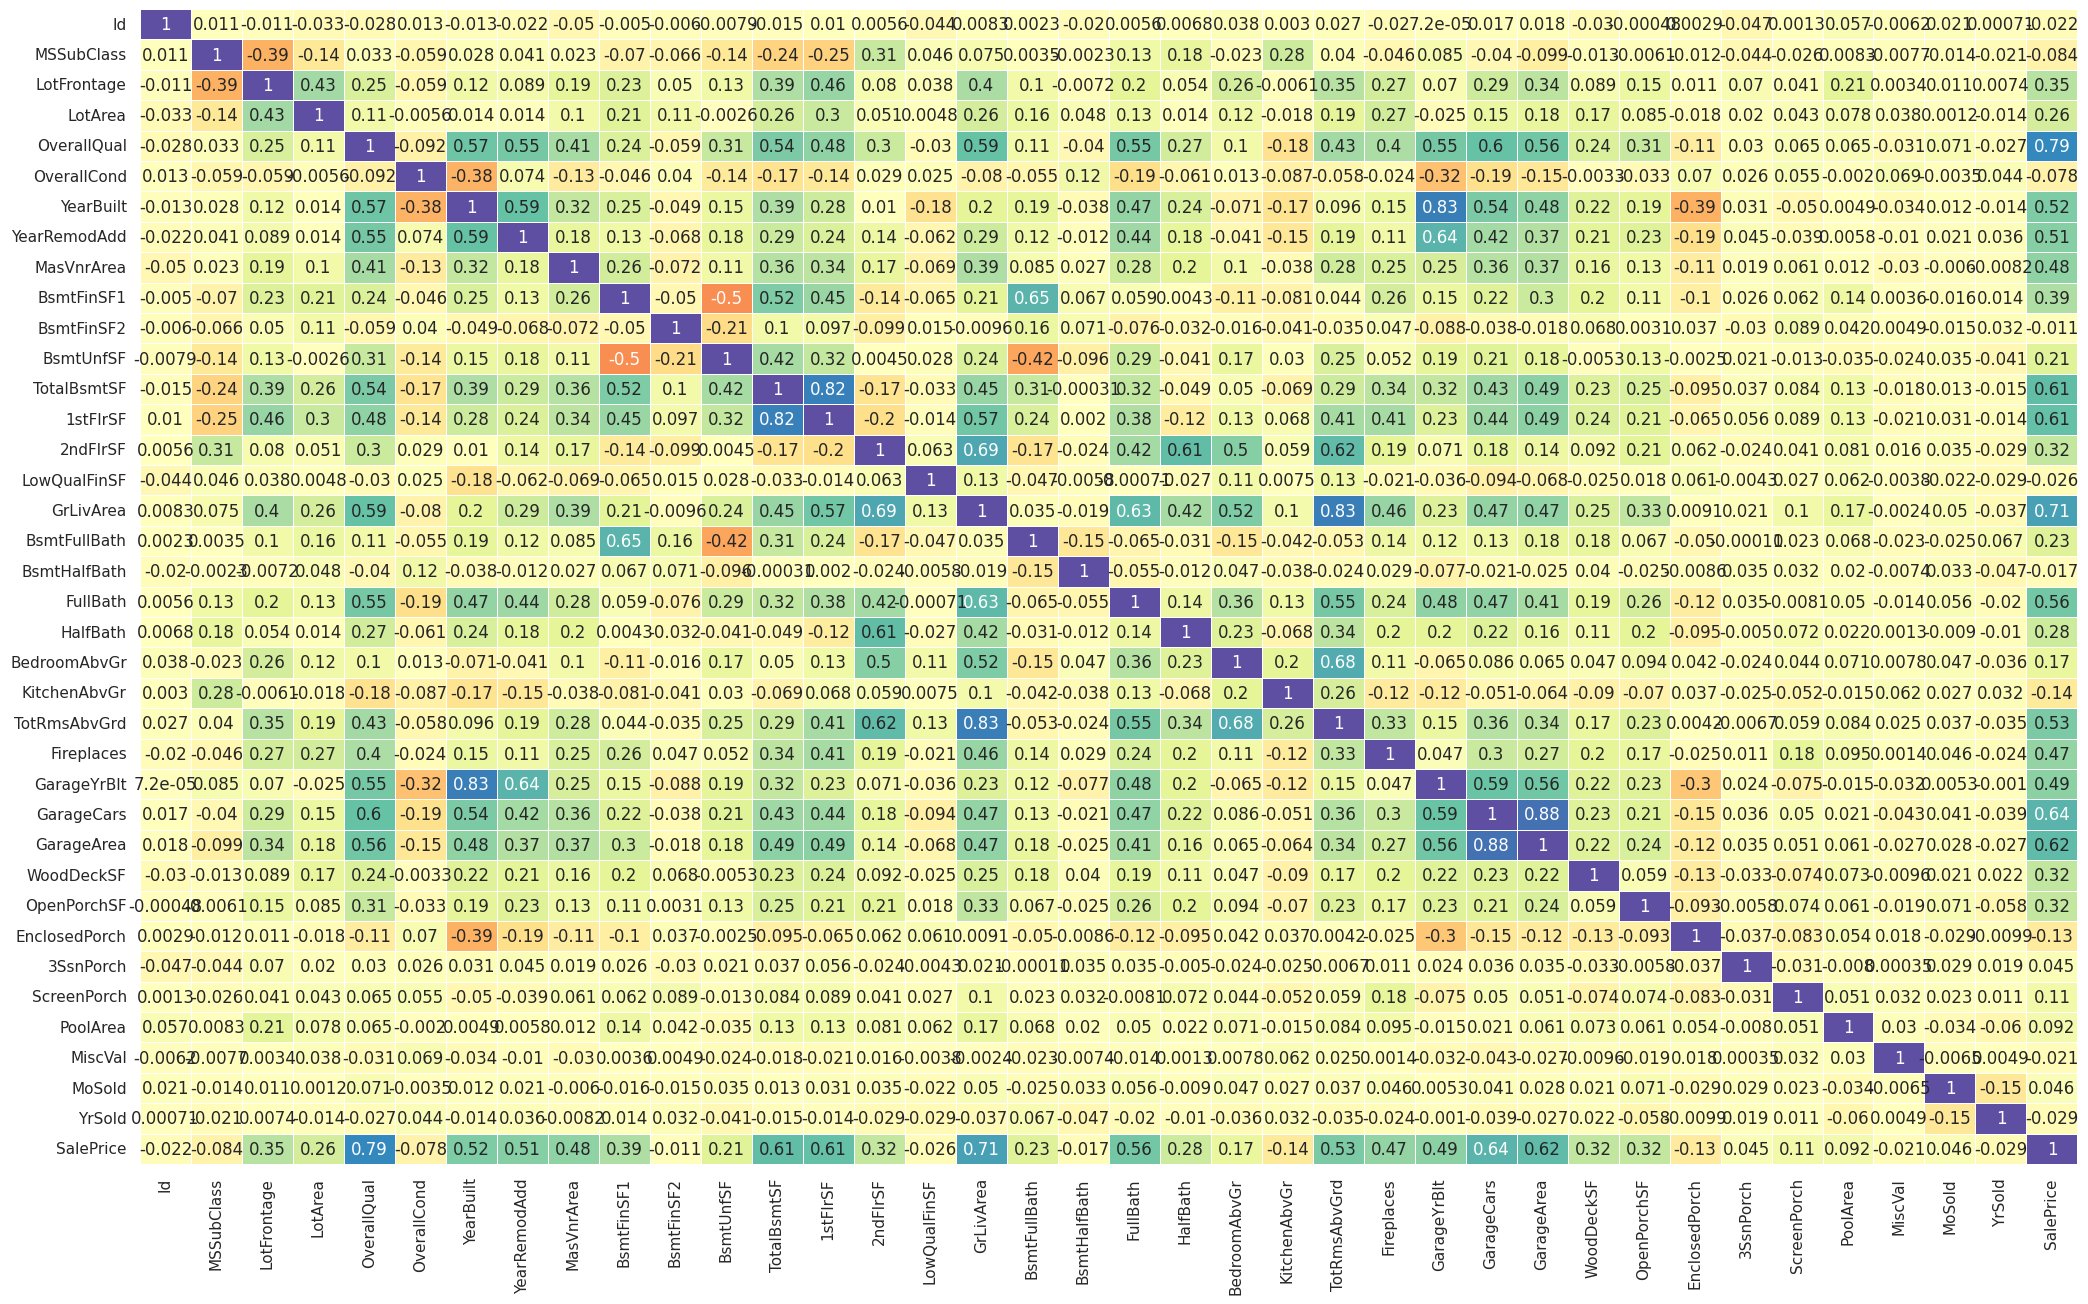

In [ ]:
# Check for correlations
sns.set(rc={'figure.figsize':(25,15)})
sns.heatmap(train.corr(numeric_only=True),
            annot=True,
            linewidths=.5,
            center=0,
            cbar=False,
            cmap="Spectral")
plt.show();

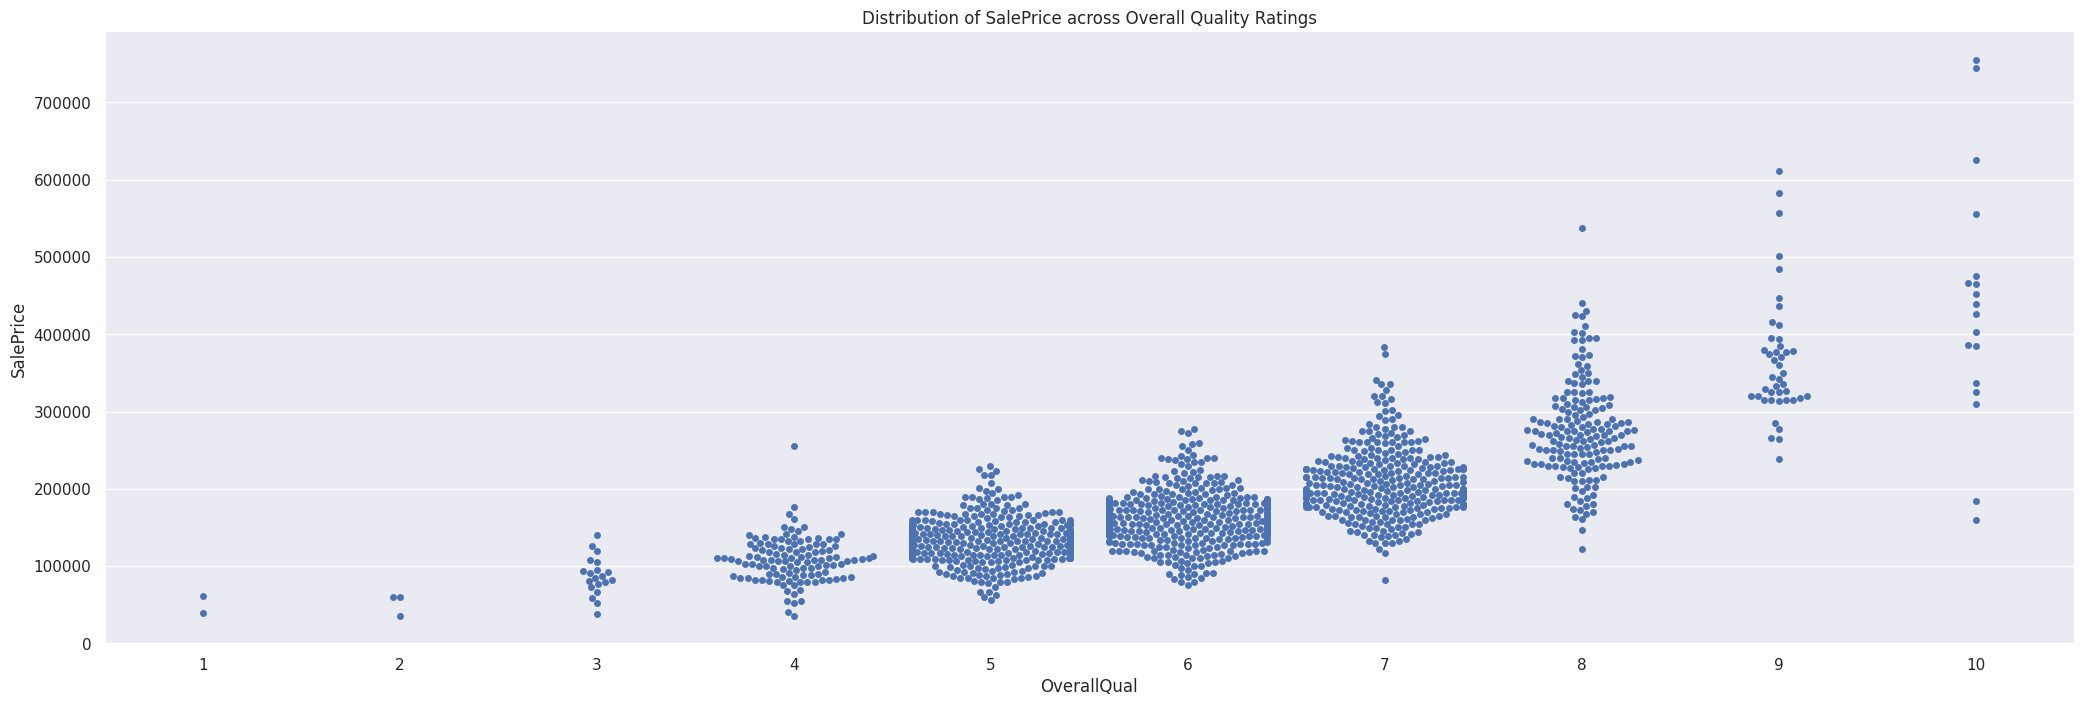

In [ ]:
# Distribution of SalePrice across Overall Quality
sns.set(rc={'figure.figsize':(10,5)})
sns.catplot(x=train["OverallQual"], y=train["SalePrice"], kind="swarm"
, height=7, aspect=3).set(title="Distribution of SalePrice across Overall Quality Ratings")
plt.show();

The swarm plot effectively shows the strong positive relationship between sale prices and overall quality, making it clear that homes with higher quality ratings tend to have higher sale prices.

## Featured Engineering for Missing Values

In [ ]:
# List of columns with missing data in train set
missing_cols = train.isna().sum()
missing_cols = missing_cols[missing_cols > 0] # selects those with count > 0
missing_percent = (train.isnull().sum() / len(train)) * 100

# put it into dataframe
missing_data = pd.DataFrame({
    'Missing Values': missing_cols,
    'Percentage': missing_percent
})
missing_data = missing_data[missing_data['Missing Values'] > 0]

print(missing_data.sort_values(by='Missing Values', ascending=False).head(20))
print(f'There are', missing_cols.shape[0], 'columns with missing data')

              Missing Values  Percentage
PoolQC                1453.0   99.520548
MiscFeature           1406.0   96.301370
Alley                 1369.0   93.767123
Fence                 1179.0   80.753425
MasVnrType             872.0   59.726027
FireplaceQu            690.0   47.260274
LotFrontage            259.0   17.739726
GarageFinish            81.0    5.547945
GarageQual              81.0    5.547945
GarageType              81.0    5.547945
GarageYrBlt             81.0    5.547945
GarageCond              81.0    5.547945
BsmtFinType2            38.0    2.602740
BsmtExposure            38.0    2.602740
BsmtFinType1            37.0    2.534247
BsmtQual                37.0    2.534247
BsmtCond                37.0    2.534247
MasVnrArea               8.0    0.547945
Electrical               1.0    0.068493
There are 19 columns with missing data


Defined Function to treat missing values

In [ ]:
def treat_missing_data(df, num_medians=None, cat_modes=None, is_train=True):
    """
    Clean missing values for both train and test dataframes.

    Parameters
    ----------
    df : DataFrame
        Input dataframe to clean.
    num_medians : dict, optional
        Precomputed medians for numeric columns (from train).
    cat_modes : dict, optional
        Precomputed modes for categorical columns (from train).
    is_train : bool, default=True
        Whether this is training data (compute stats) or test data (apply stats).

    Returns
    -------
    df : DataFrame
        Cleaned dataframe with no missing values.
    num_medians : dict
        Dictionary of computed medians for numeric columns.
    cat_modes : dict
        Dictionary of computed modes for categorical columns.
    """

    df = df.copy()

    # Separate column types
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    num_cols = df.select_dtypes(include=["number"]).columns

    # =============================
    # TRAIN: compute statistics
    # =============================
    if is_train:
        num_medians = {col: df[col].median() for col in num_cols}
        cat_modes = {col: df[col].mode(dropna=True)[0] if not df[col].mode(dropna=True).empty else "None"
                     for col in cat_cols}

    # =============================
    # APPLY: impute missing values
    # =============================

    # Fill numeric columns with train medians
    for col in num_cols:
        fill_value = num_medians.get(col, 0)  # fallback 0 if unseen column
        df[col] = df[col].fillna(fill_value)

    # Fill categorical columns with train modes
    for col in cat_cols:
        fill_value = cat_modes.get(col, "None")  # fallback "None"
        df[col] = df[col].fillna(fill_value)

        # Handle unseen categories in test → replace with "Other"
        if not is_train:
            known_categories = set(df[col].unique()).union({fill_value})
            df[col] = df[col].where(df[col].isin(known_categories), "Other")

    return df, num_medians, cat_modes

In [ ]:
# Train: learn medians & modes
train_clean, num_medians, cat_modes = treat_missing_data(train, is_train=True)

# Test: apply same medians & modes
test_clean, _, _ = treat_missing_data(test,
                                      num_medians=num_medians,
                                      cat_modes=cat_modes,
                                      is_train=False)

# Confirm no missing values
print(train_clean.isna().sum().sum())  # should be 0
print(test_clean.isna().sum().sum())   # should be 0

0
0


## Data Preprocessing

In [ ]:
# split train data
y = train_clean["SalePrice"]
X = train_clean.drop(columns=["SalePrice"])

In [ ]:
# Separate features
cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols = X.select_dtypes(include=["number"]).columns

# Preprocessor for Ridge/Lasso (scaling + encoding)
rl_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),       # scaling numeric features
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)  # one-hot for categorical
    ]
)

# Preprocessor for Tree-based models (only encoding, no scaling)
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),  # Leave numeric features as-is, no scaling
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)  # One-hot encode categoricals
    ]
)

In [ ]:
# split X into training & validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## Linear Regression Pipeline (using Ridge/Lasso Regression)

In [ ]:
# Lasso pipeline
lasso_pipeline = Pipeline(steps=[
    ("preprocessor", rl_preprocessor),  # Same preprocessing
    ("model", Lasso(alpha=0.001))           # Lasso regression
])

## Tree-Based Pipeline (Random Forest, Gradient Boosting and XGB)

In [ ]:
# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),  # Encode categoricals, pass numeric raw
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

# Gradient Boosting pipeline
gb_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),  # Same preprocessing
    ("model", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42))
])

# XGB pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),  # Same preprocessing
    ("model", XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42))
])

## Building Model

In [ ]:
def evaluate_model(pipeline, X_train, y_train, X_valid, y_valid, model_name="Model"):
    """
    Fit a pipeline on training data, predict on validation data,
    and compute RMSE, R², and MAE.

    Parameters:
    -----------
    pipeline : sklearn pipeline (already defined)
    X_train, y_train : training data
    X_valid, y_valid : validation data
    model_name : str, optional (for display purposes)

    Returns:
    --------
    dict : containing rmse, r2, mae
    """
    # Fit model
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred_valid = pipeline.predict(X_valid)

    # function to compute adjusted R-squared
    def adj_r2_score(predictors, targets, predictions):
        r2 = r2_score(targets, predictions)
        n = predictors.shape[0]
        k = predictors.shape[1]
        return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


    # Metrics
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
    r2 = r2_score(y_valid, y_pred_valid)
    mae = mean_absolute_error(y_valid, y_pred_valid)
    adj_r2 = adj_r2_score(X_valid, y_valid, y_pred_valid)

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": f"{rmse:.3f}",
            "MAE": f"{mae:.3f}",
            "R²": f"{r2:.3f}",
            "Adjusted R²": f"{adj_r2:.3f}"
        },
        index=[0],
    )

    return df_perf


In [ ]:
# Lasso
lasso_results = evaluate_model(lasso_pipeline, X_train, y_train, X_valid, y_valid, model_name="Lasso")
lasso_results

,RMSE,MAE,R²,Adjusted R²
0,27326.154,17567.108,0.893,0.863


In [ ]:
# Random Forest
rf_results = evaluate_model(rf_pipeline, X_train, y_train, X_valid, y_valid, model_name="Random Forest")
rf_results

,RMSE,MAE,R²,Adjusted R²
0,27439.556,16990.126,0.893,0.862


In [ ]:
# Gradient Boosting
gb_results = evaluate_model(gb_pipeline, X_train, y_train, X_valid, y_valid, model_name="Gradient Boosting")
gb_results

,RMSE,MAE,R²,Adjusted R²
0,25354.253,15858.074,0.908,0.882


In [ ]:
xgb_results = evaluate_model(xgb_pipeline, X_train, y_train, X_valid, y_valid, "XGBoost")
xgb_results

,RMSE,MAE,R²,Adjusted R²
0,24423.114,15675.520,0.915,0.891


## Model Comparison

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [lasso_results.T, rf_results.T, gb_results.T,xgb_results.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Lasso Model",
    "Random Forest Estimator",
    "Gradient Boost Estimator",
    "XGB"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Lasso Model,Random Forest Estimator,Gradient Boost Estimator,XGB
RMSE,27326.154,27439.556,25354.253,24423.114
MAE,17567.108,16990.126,15858.074,15675.520
R²,0.893,0.893,0.908,0.915
Adjusted R²,0.863,0.862,0.882,0.891


- The best model is XGB with highest values for R² and Adj. R², and lowest values for RMSE and MAE.

- So retrain XGB model on full training set (X, y)

- Then we use the XGB to predict the SalePrice for the test data.

In [ ]:
# Fit best model on full training data
best_model = xgb_pipeline.fit(X, y)

# Predict on test_clean
y_pred_test = best_model.predict(test_clean)

In [ ]:
# Attach predictions to test DataFrame
test_with_preds = test.copy()  # keep original test data (with Id column)
test_with_preds["SalePrice"] = y_pred_test  # add predicted_saleprice as new column

In [ ]:
# Display top 5 rows of test data with predicted Saleprice
test_with_preds.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,123946.570312
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,156981.468750
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,177560.109375
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,191968.656250
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,190450.125000


## Plots of Predicted SalePrice

- Distribution of Predicted SalePrice across Overall Quality

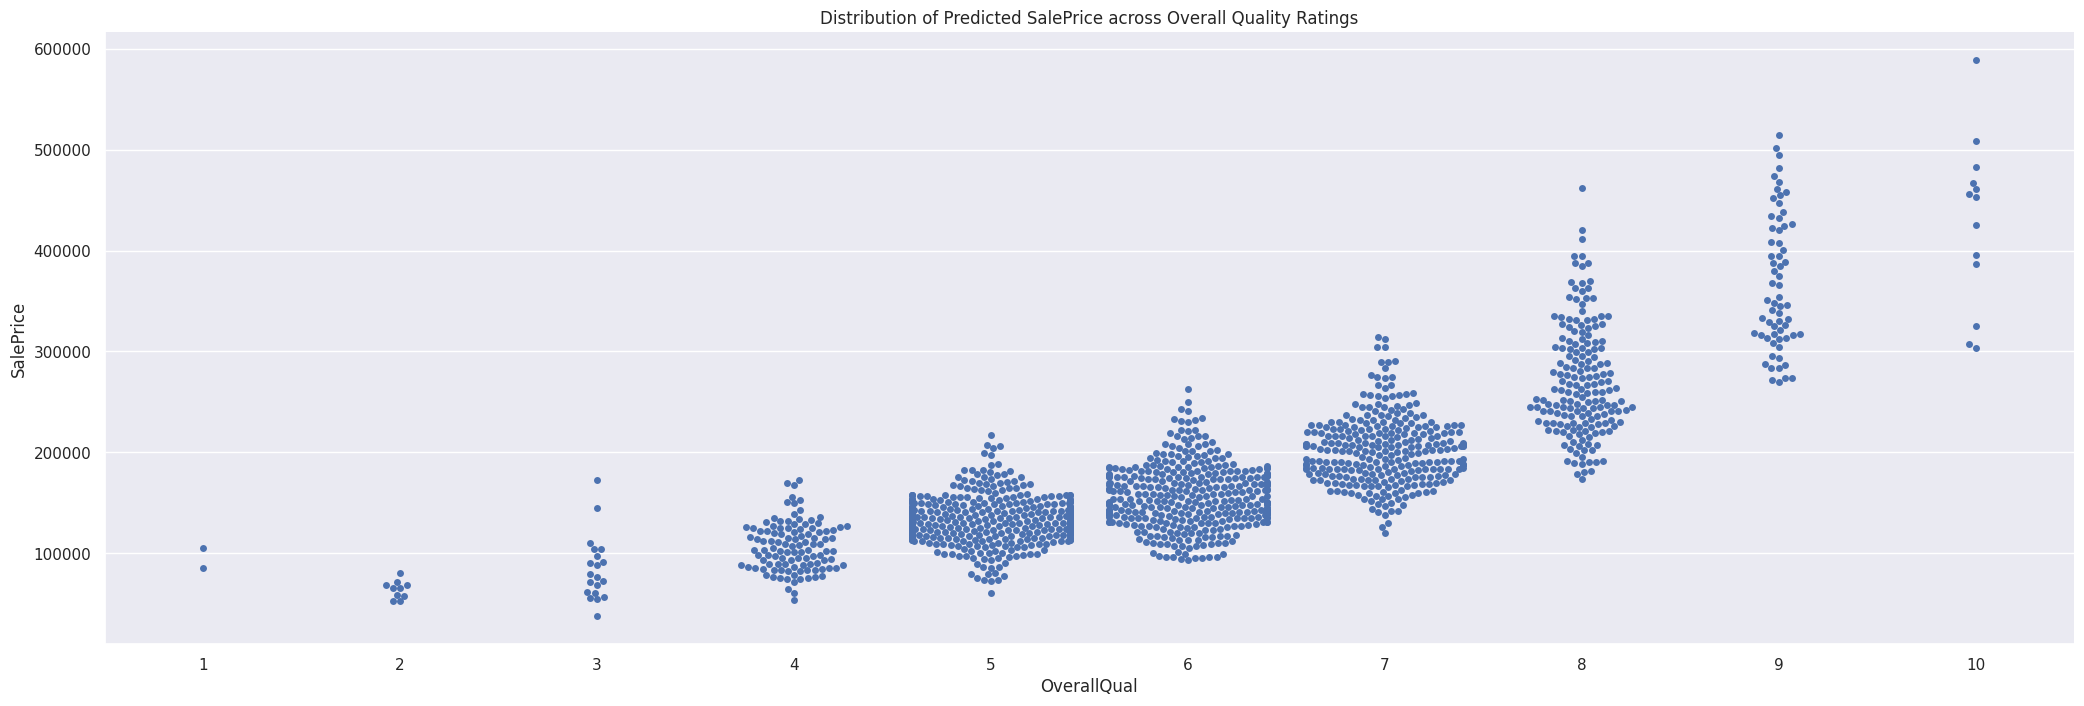

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
sns.catplot(x=test_with_preds["OverallQual"], y=test_with_preds["SalePrice"], kind="swarm"
, height=7, aspect=3).set(title="Distribution of Predicted SalePrice across Overall Quality Ratings")
plt.show();

- Actual vs Predicted SalePrice

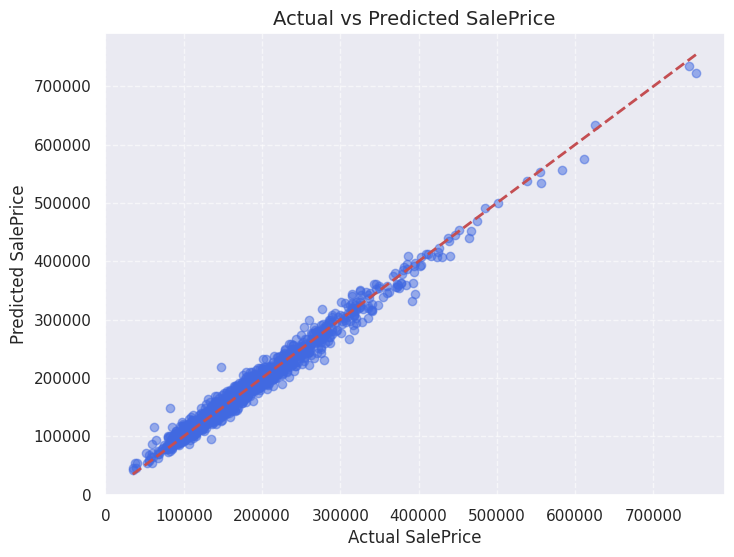

In [ ]:
# Predict on validation (or training) set
y_pred_train = best_model.predict(X)

# Scatter plot of Actual vs Predicted SalePrice
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred_train, alpha=0.5, color="royalblue")

# Add diagonal line (perfect predictions)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)

plt.xlabel("Actual SalePrice", fontsize=12)
plt.ylabel("Predicted SalePrice", fontsize=12)
plt.title("Actual vs Predicted SalePrice", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show();

## Conclusion

- We can predict the Sale price of homes using the model

- The swarm plot of the predicted SalePrice against OverallQual for the test data shows a very similar trend to the plot of the actual data. This is a positive sign, as it indicates that my model has learned the relationship between these two variables well and is making reasonable predictions on unseen data.
- The closely clustered points of actual and predicted price around the diagonal line of the scatterd plot indicates that The plot shows that the model is performing quite well overall.
- This indicates that the model's predictions are, for the most part, very close to the actual sale prices.

In [ ]:
# Fit best model on full training data
best_model = xgb_pipeline.fit(X, y)

# Predict on test_clean
y_pred_test = best_model.predict(test_clean)

# Create DataFrame with only Id and prediction
submission_df = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_pred_test
})

submission_df.to_csv("submission.csv", index=False)
print("Submission file created successfully!")
# Show top 5 rows
print("\nTop five predictions:")
print(submission_df.head())

Submission file created successfully!

Top five predictions:
     Id      SalePrice
0  1461  123946.570312
1  1462  156981.468750
2  1463  177560.109375
3  1464  191968.656250
4  1465  190450.125000
